# Dependencies

In [6]:
!pip install ucimlrepo
!pip install scikit-learn

In [7]:
import pandas as pd
from ucimlrepo import fetch_ucirepo 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, mean_absolute_error, log_loss, recall_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import cross_validate
from sklearn.model_selection import validation_curve
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import IsolationForest
import seaborn as sns
import numpy as np

# Data Preparation

In [8]:
# fetch dataset 
ai4i_2020_predictive_maintenance_dataset = fetch_ucirepo(id=601) 
  
# data (as pandas dataframes) 
X = ai4i_2020_predictive_maintenance_dataset.data.features 
y = ai4i_2020_predictive_maintenance_dataset.data.targets 

In [9]:
# Check feature data
X.head()

,Type,Air temperature,Process temperature,Rotational speed,Torque,Tool wear
0,M,298.1,308.6,1551,42.8,0
1,L,298.2,308.7,1408,46.3,3
2,L,298.1,308.5,1498,49.4,5
3,L,298.2,308.6,1433,39.5,7
4,L,298.2,308.7,1408,40.0,9


In [10]:
# Convert categorical data into numerical representation
X.loc[X['Type'] == 'L', 'Type'] = 0
X.loc[X['Type'] == 'M', 'Type'] = 1
X.loc[X['Type'] == 'H', 'Type'] = 2
X.head()

,Type,Air temperature,Process temperature,Rotational speed,Torque,Tool wear
0,1,298.1,308.6,1551,42.8,0
1,0,298.2,308.7,1408,46.3,3
2,0,298.1,308.5,1498,49.4,5
3,0,298.2,308.6,1433,39.5,7
4,0,298.2,308.7,1408,40.0,9


In [11]:
# Check targets data
y.head()

,Machine failure,TWF,HDF,PWF,OSF,RNF
0,0,0,0,0,0,0
1,0,0,0,0,0,0
2,0,0,0,0,0,0
3,0,0,0,0,0,0
4,0,0,0,0,0,0


In [12]:
# Get Machine failure data
y_fail = y['Machine failure']
y_fail.head()

0    0
1    0
2    0
3    0
4    0
Name: Machine failure, dtype: int64

array([[<Axes: title={'center': 'Air temperature'}>,
        <Axes: title={'center': 'Process temperature'}>],
       [<Axes: title={'center': 'Rotational speed'}>,
        <Axes: title={'center': 'Torque'}>],
       [<Axes: title={'center': 'Tool wear'}>, <Axes: >]], dtype=object)

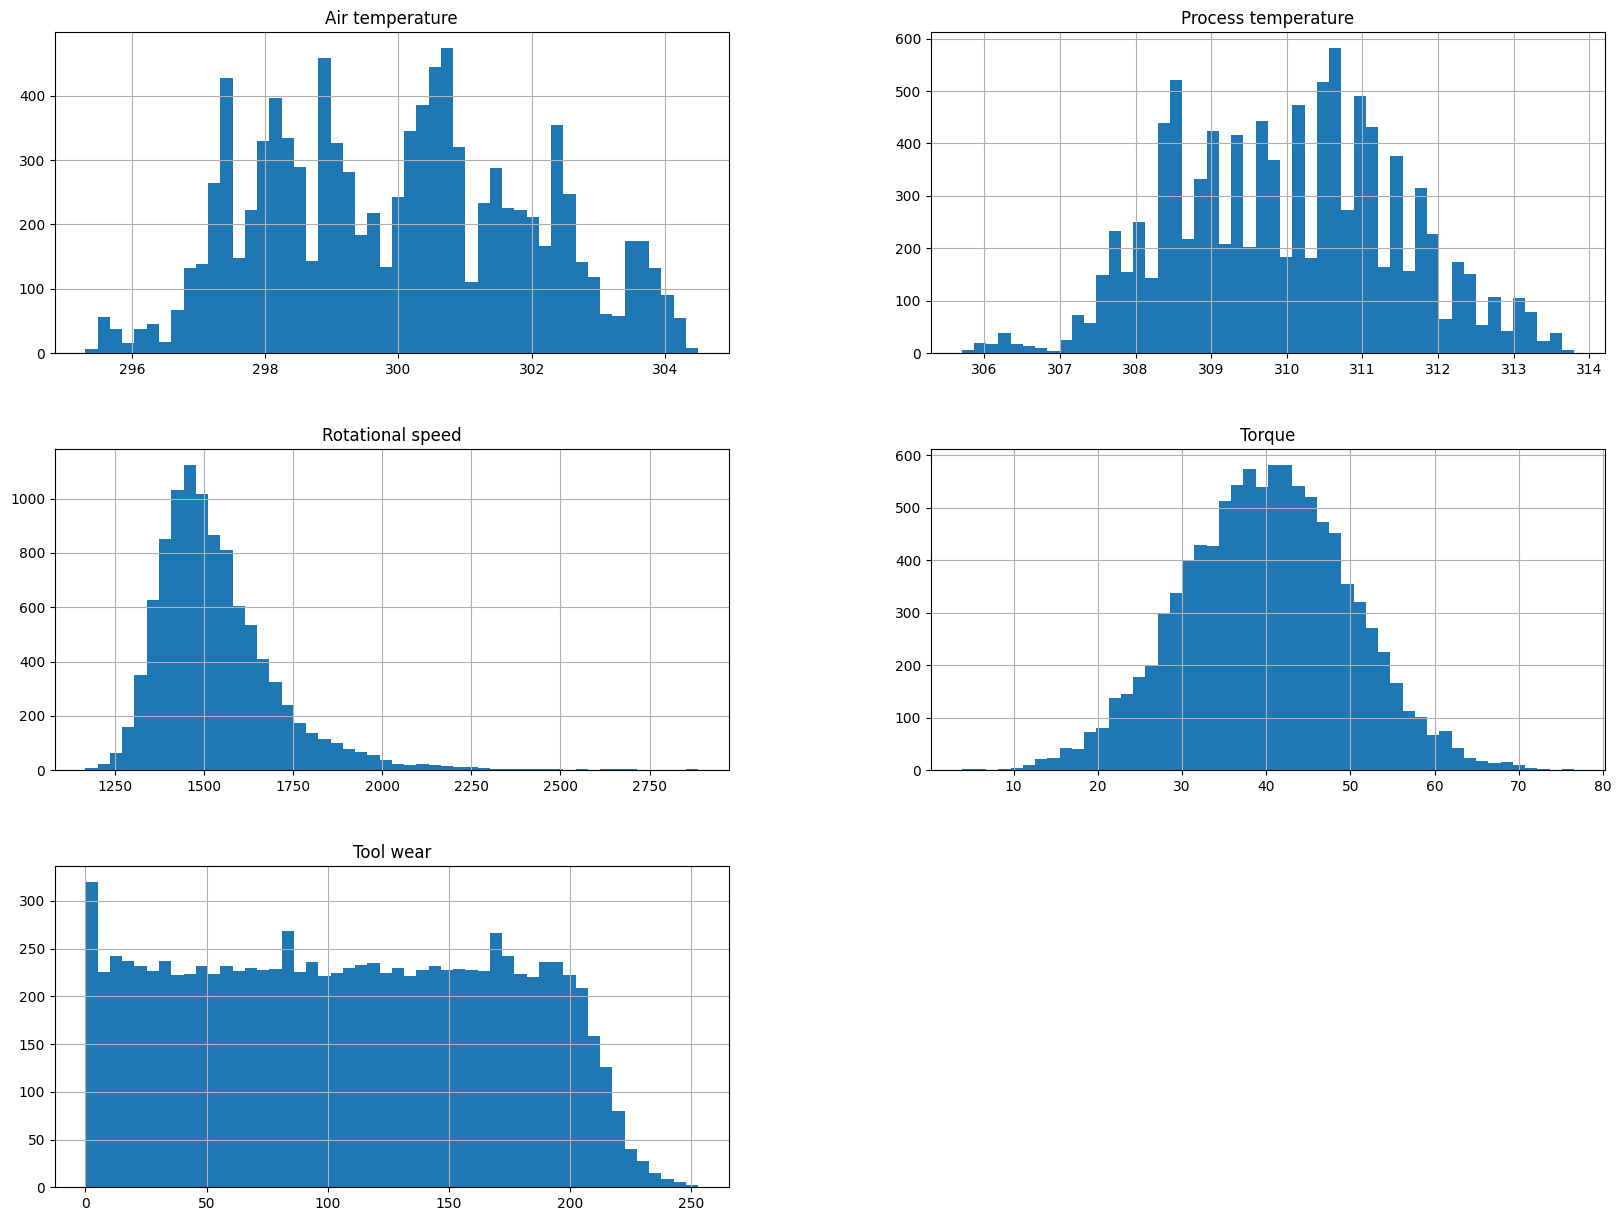

In [13]:
# Check how feature data looks like to get more understanding of data
X.hist(bins=50, figsize=(20,15))

In [14]:
X.describe()

,Air temperature,Process temperature,Rotational speed,Torque,Tool wear
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,300.004930,310.005560,1538.776100,39.986910,107.951000
std,2.000259,1.483734,179.284096,9.968934,63.654147
min,295.300000,305.700000,1168.000000,3.800000,0.000000
25%,298.300000,308.800000,1423.000000,33.200000,53.000000
50%,300.100000,310.100000,1503.000000,40.100000,108.000000
75%,301.500000,311.100000,1612.000000,46.800000,162.000000
max,304.500000,313.800000,2886.000000,76.600000,253.000000


In [15]:
y_fail.describe()

count    10000.000000
mean         0.033900
std          0.180981
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: Machine failure, dtype: float64

In [16]:
# Split data set into training and test sets
# Apply random seed to allow repetition of output
# Apply stratify to get good representation of failure and non-failure between training and test sets
xtrain, xtest, ytrain, ytest = train_test_split(X, y_fail, test_size=0.2, random_state=1, shuffle=True, stratify=y_fail)

# Checking split if stratified
print(ytrain.value_counts())
print(ytest.value_counts())
print(ytrain.value_counts()/ytest.value_counts()) # values of 0 and 1 should be similar for this ratio.

Machine failure
0    7729
1     271
Name: count, dtype: int64
Machine failure
0    1932
1      68
Name: count, dtype: int64
Machine failure
0    4.000518
1    3.985294
Name: count, dtype: float64


In [17]:
# Apply Feature scaling to transform the scaling of different features into similar scales.
scaler = StandardScaler()
xtrain_scaled = scaler.fit_transform(xtrain)
xtest_scaled = scaler.transform(xtest)

# Functions

In [18]:
def confuse_matrix(ytest, ypred):
    '''
    Compute the confusion matrix
    [[TN   FP]  # True Negatives (TN), False Positives (FP)
     [  FN   TP]] # False Negatives (FN), True Positives (TP)
    '''
    cm = confusion_matrix(ytest, ypred)
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                                 display_labels=['Class 0', 'Class 1'])
    
    fig, ax = plt.subplots(figsize=(4, 3))
    disp.plot(ax=ax, cmap='Blues', values_format='d')

# KNN Implementation

In [19]:
# KNN Basic Implementation Form - n=2
knn = KNeighborsClassifier(n_neighbors=2)
knn.fit(xtrain, ytrain)
ypred = knn.predict(xtest)
ypred_prob = knn.predict_proba(xtest)
accuracy = accuracy_score(ytest, ypred)
print('Accuracy:', accuracy)
precision = precision_score(ytest, ypred)
print('Precision:', precision)
recall = recall_score(ytest, ypred)
print('Recall:', recall)

Accuracy: 0.9665
Precision: 0.5263157894736842
Recall: 0.14705882352941177


In [20]:
# Validation Curve kNN 2-50
knn = KNeighborsClassifier()
values = np.arange(2,50, 1)
estimator = knn
param_name, param_range = 'n_neighbors', values
scoring = 'recall'
train_scores, val_scores = validation_curve(estimator, xtrain, ytrain, param_name=param_name, 
                                                 param_range=param_range, scoring=scoring, cv=5)
mean_train_score = np.mean(train_scores, axis=1)
mean_val_scores = np.mean(val_scores, axis=1)

In [21]:
# Get best k parameter
best_k_params = values[mean_val_scores.tolist().index(max(mean_val_scores.tolist()))]
print('Best k: ' + str(best_k_params))

Best k: 3


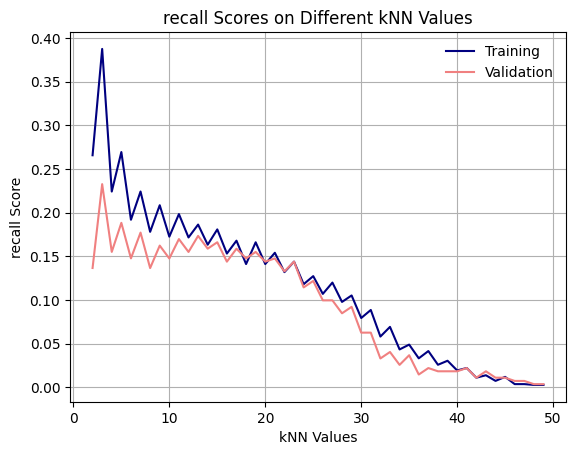

In [22]:
# Plot validation curve
plt.figure(scoring)
plt.plot(values, mean_train_score, label='Training', color='navy')
plt.plot(values, mean_val_scores, label='Validation', color='lightcoral')
plt.xlabel('kNN Values')
plt.ylabel(str(scoring) + ' Score')
plt.title(str(scoring) + ' Scores on Different kNN Values')
plt.grid(visible=True)
plt.legend(frameon=False)

In [23]:
# Apply optimal hyperparameter from validation curve
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(xtrain, ytrain)
ypred_knn = knn.predict(xtest)
ypred_prob = knn.predict_proba(xtest)
accuracy_knn = accuracy_score(ytest, ypred_knn)
print('Accuracy:', accuracy_knn)
precision_knn = precision_score(ytest, ypred_knn)
print('Precision:', precision_knn)
recall_knn = recall_score(ytest, ypred_knn)
print('Recall:', recall_knn)

Accuracy: 0.967
Precision: 0.53125
Recall: 0.25


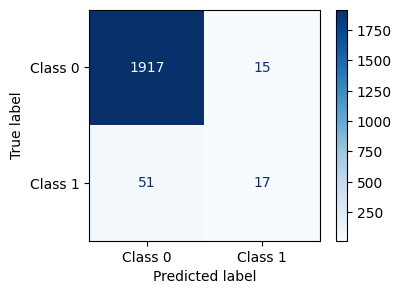

In [24]:
# Compute the confusion matrix
confuse_matrix(ytest, ypred_knn)

In [25]:
# Add labels of confusion matrix
x_knn = xtest.copy()
x_knn
x_knn.loc[(ypred_knn==0) & (ytest==0), 'knn'] = 'True negative'
x_knn.loc[(ypred_knn==1) & (ytest==0), 'knn'] = 'False positive'
x_knn.loc[(ypred_knn==0) & (ytest==1), 'knn'] = 'False negative'
x_knn.loc[(ypred_knn==1) & (ytest==1), 'knn'] = 'True positive'

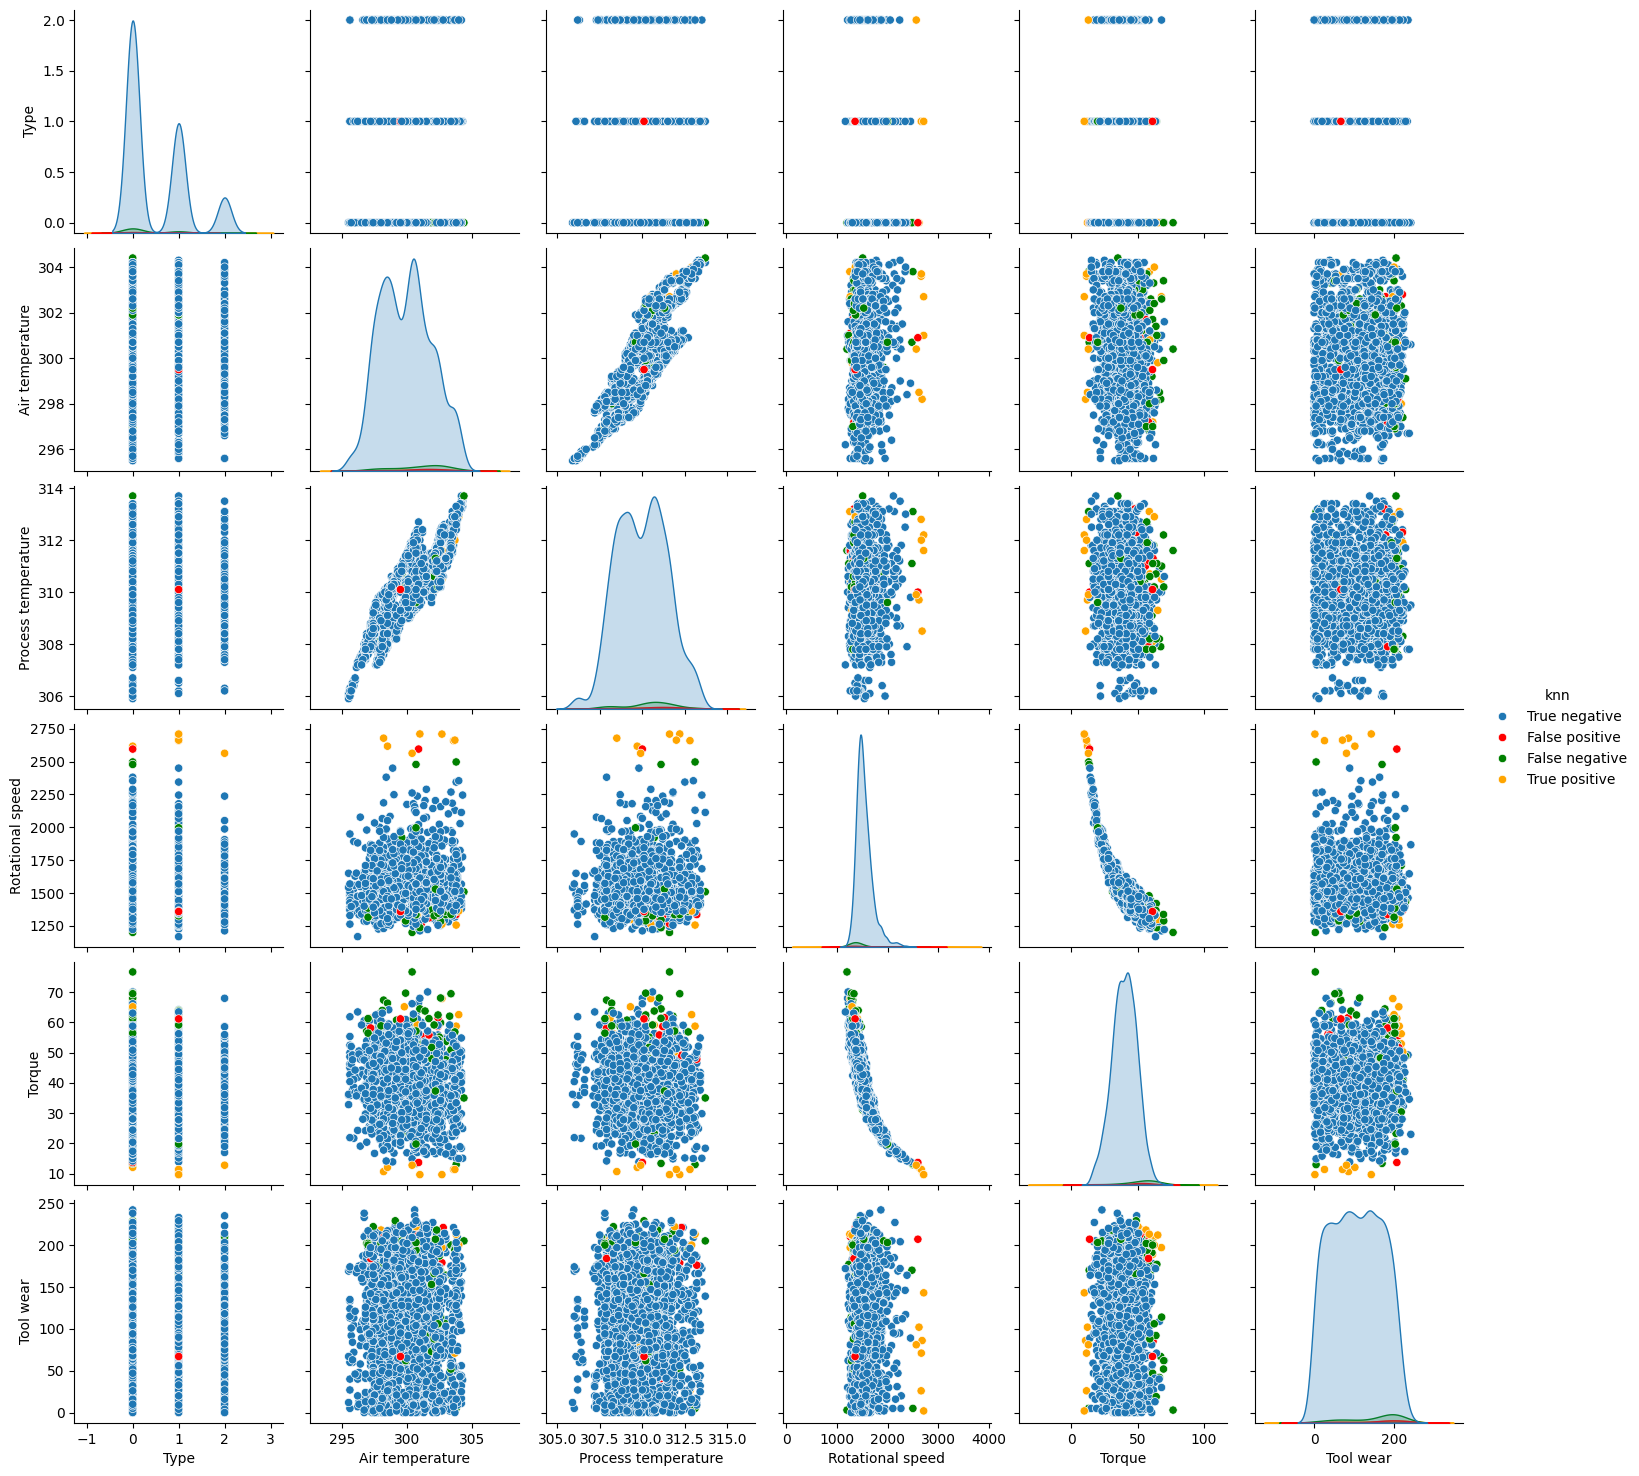

In [26]:
# Plot feature pairs
sns.pairplot(x_knn, 
             hue='knn', 
             hue_order=['True negative', 'False positive','False negative', 'True positive'],
             palette=['#1f77b4', 'red', 'green', 'orange'])

# Decision Tree Implementation

In [27]:
# Decision Tree Basic Implementation Form 
dtree = tree.DecisionTreeClassifier()
dtree_fit = dtree.fit(xtrain, ytrain)
ypred_dtree = dtree_fit.predict(xtest)
ypred_prob = dtree_fit.predict_proba(xtest)
accuracy_dtree = accuracy_score(ytest, ypred_dtree)
print('Accuracy:', accuracy_dtree)
precision_dtree = precision_score(ytest, ypred_dtree)
print('Precision:', precision_dtree)
recall_dtree = recall_score(ytest, ypred_dtree)
print('Recall:', recall_dtree)


Accuracy: 0.975
Precision: 0.6363636363636364
Recall: 0.6176470588235294


In [28]:
# Hyperparameter Tuning of Decision Tree 
# Define the parameter grid to tune the hyperparameters
param_grid = {
    'max_depth': [10, 20, 30, None],
    'criterion': ['gini', 'entropy', 'log_loss'],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

#Perform grid search from hyperparameters to find optimal performance
dtree = tree.DecisionTreeClassifier()
grid_search_dtree = GridSearchCV(estimator=dtree, param_grid=param_grid, 
                           cv=5, n_jobs=-1, verbose=2, scoring='recall')
grid_search_dtree.fit(xtrain, ytrain)
print('best score: {:.3f}, best params: {}'.format(grid_search_dtree.best_score_, grid_search_dtree.best_params_))

Fitting 5 folds for each of 108 candidates, totalling 540 fits
best score: 0.713, best params: {'criterion': 'gini', 'max_depth': 30, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [29]:
# Provide top 5 from grid search table and best parameters.
gs_table = pd.DataFrame(grid_search_dtree.cv_results_)
gs_sort = gs_table.sort_values('rank_test_score', ascending=True)
gs_sort.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_criterion,param_max_depth,param_min_samples_leaf,param_min_samples_split,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
18,0.098338,0.037533,0.018005,0.013380,gini,30,1,2,"{'criterion': 'gini', 'max_depth': 30, 'min_sa...",0.796296,0.722222,0.685185,0.777778,0.581818,0.712660,0.076422,1
9,0.062108,0.019334,0.023257,0.017724,gini,20,1,2,"{'criterion': 'gini', 'max_depth': 20, 'min_sa...",0.796296,0.703704,0.666667,0.796296,0.600000,0.712593,0.075997,2
27,0.087445,0.060341,0.012151,0.003603,gini,None,1,2,"{'criterion': 'gini', 'max_depth': None, 'min_...",0.796296,0.685185,0.685185,0.759259,0.618182,0.708822,0.062496,3
90,0.073845,0.039428,0.013680,0.007500,log_loss,30,1,2,"{'criterion': 'log_loss', 'max_depth': 30, 'mi...",0.759259,0.777778,0.648148,0.740741,0.581818,0.701549,0.074652,4
10,0.067136,0.017797,0.015422,0.007770,gini,20,1,5,"{'criterion': 'gini', 'max_depth': 20, 'min_sa...",0.796296,0.648148,0.703704,0.740741,0.600000,0.697778,0.068717,5


In [30]:
# Apply optimal hyperparameter from grid search
best_dtree = grid_search_dtree.best_estimator_
ypred_dtree = best_dtree.predict(xtest)
accuracy_dtree = accuracy_score(ytest, ypred_dtree)
print('Accuracy:', accuracy_dtree)
precision_dtree = precision_score(ytest, ypred_dtree)
print('Precision:', precision_dtree)
recall_dtree = recall_score(ytest, ypred_dtree)
print('Recall:', recall_dtree)


Accuracy: 0.9735
Precision: 0.6086956521739131
Recall: 0.6176470588235294


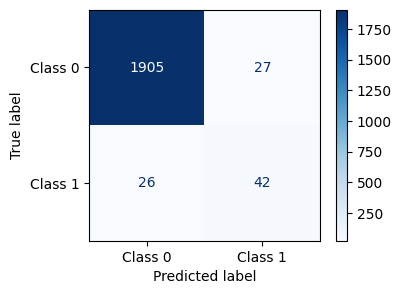

In [31]:
# Compute the confusion matrix
confuse_matrix(ytest, ypred_dtree)

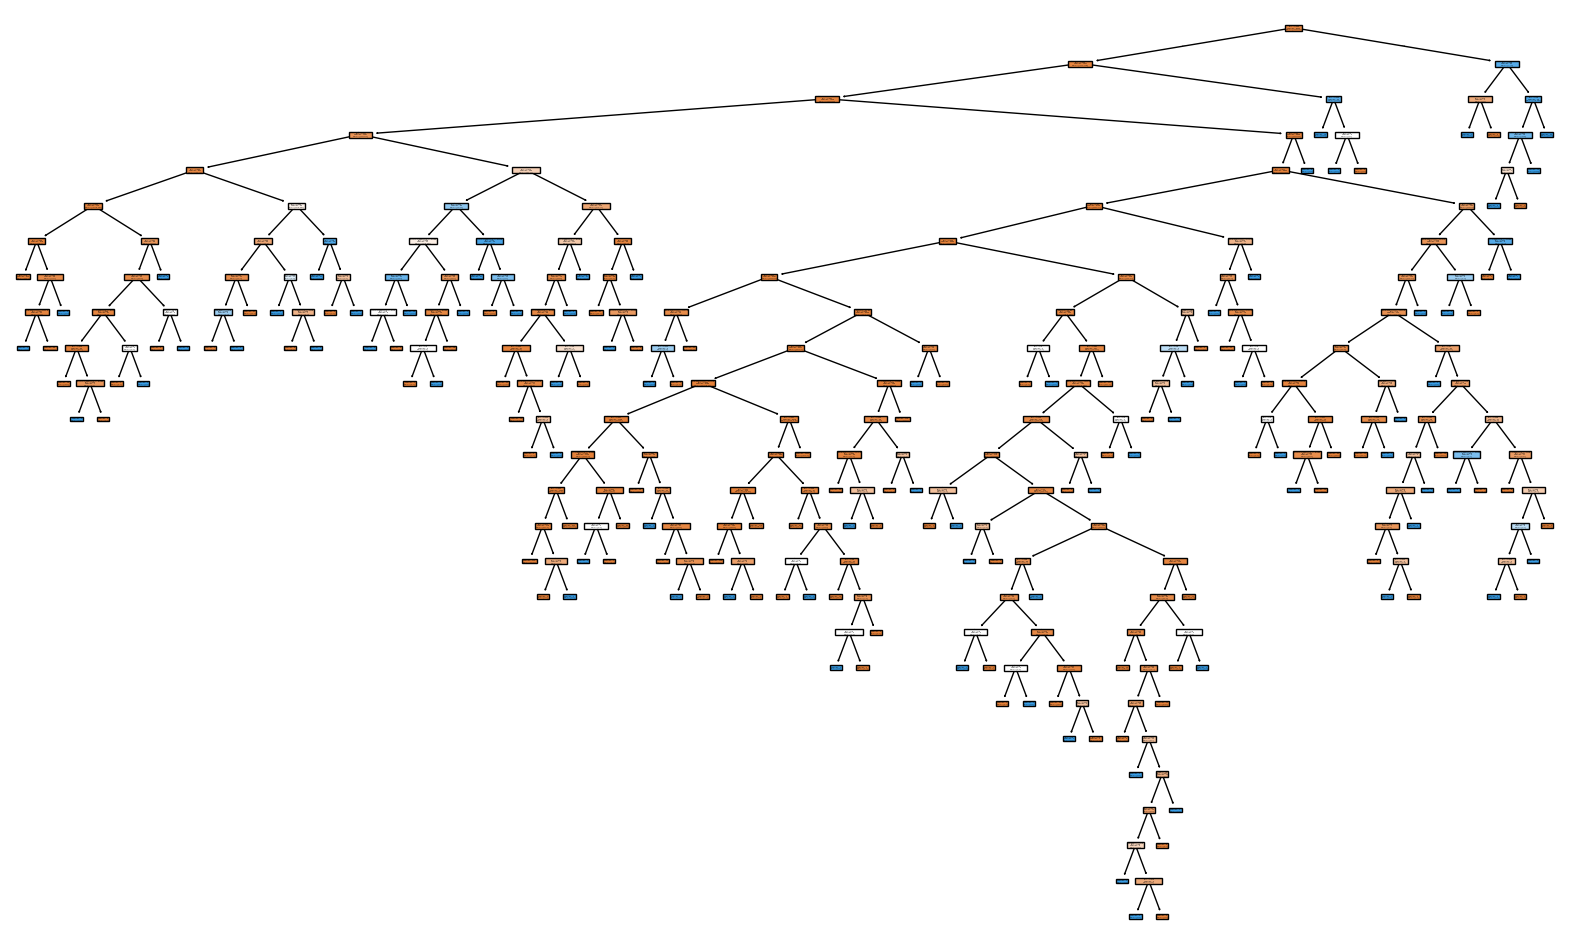

In [32]:
# Plotting entire decision tree
plt.figure(figsize=(20, 12))
tree.plot_tree(best_dtree,               
               filled=True, 
               feature_names=X.columns)
plt.show()

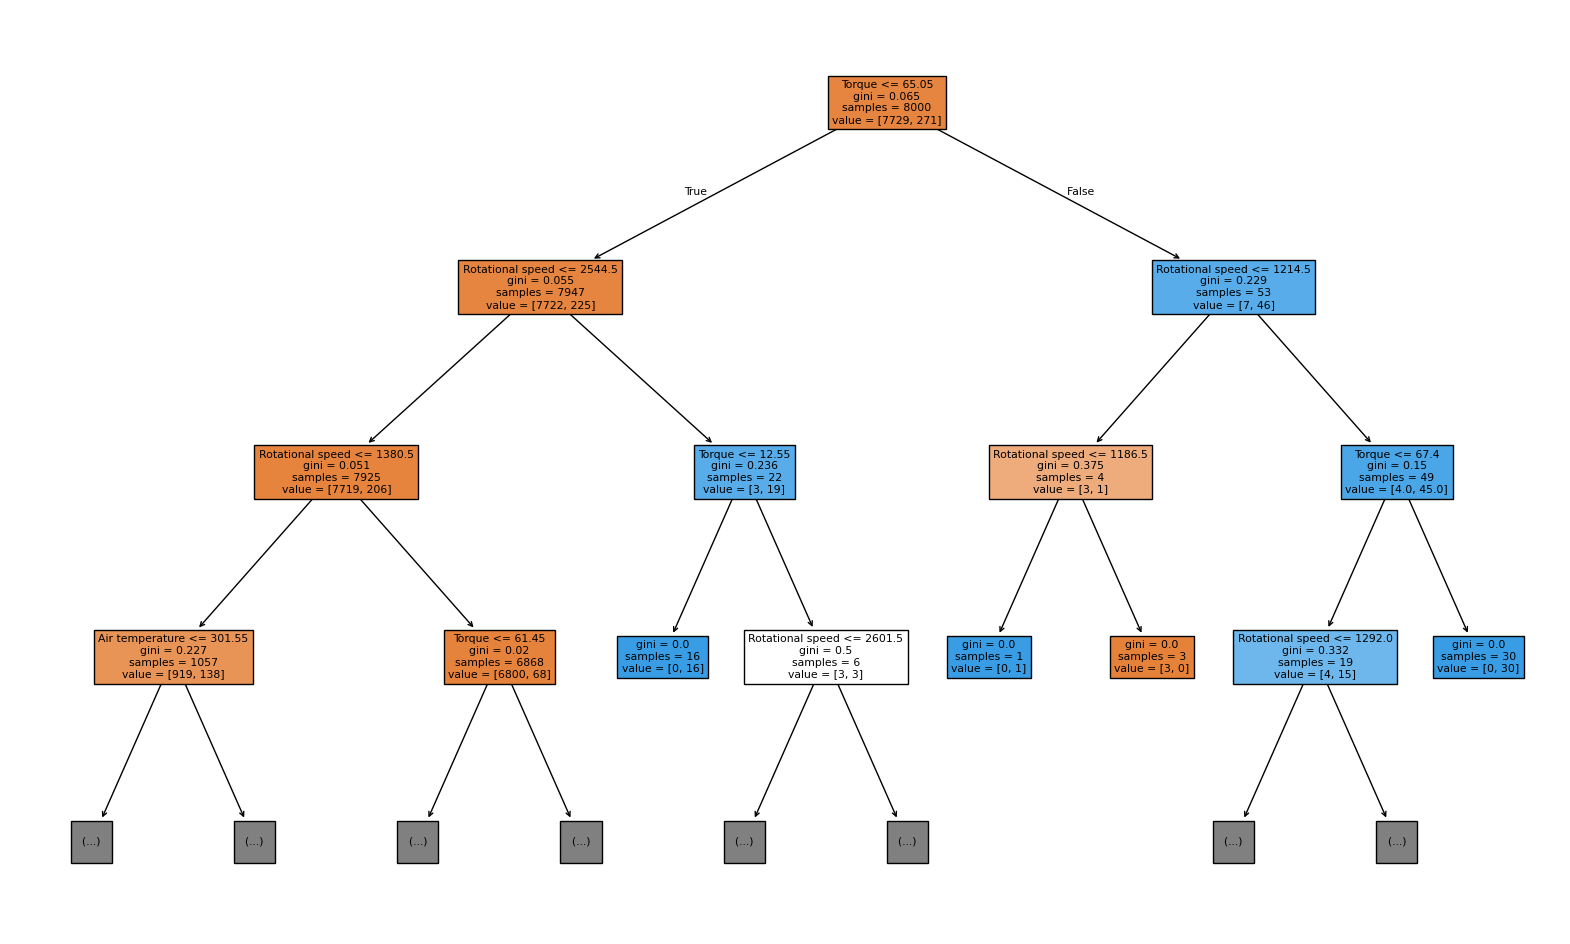

In [33]:
# Plotting decision tree with depth 3
plt.figure(figsize=(20, 12))
tree.plot_tree(best_dtree, 
               max_depth=3,              # Only show first 3 levels
               filled=True, 
               feature_names=X.columns)
plt.show()

In [34]:
x_dtree = xtest.copy()
x_dtree.loc[(ypred_dtree==0) & (ytest==0), 'Decision Tree'] = 'True negative'
x_dtree.loc[(ypred_dtree==1) & (ytest==0), 'Decision Tree'] = 'False positive'
x_dtree.loc[(ypred_dtree==0) & (ytest==1), 'Decision Tree'] = 'False negative'
x_dtree.loc[(ypred_dtree==1) & (ytest==1), 'Decision Tree'] = 'True positive'

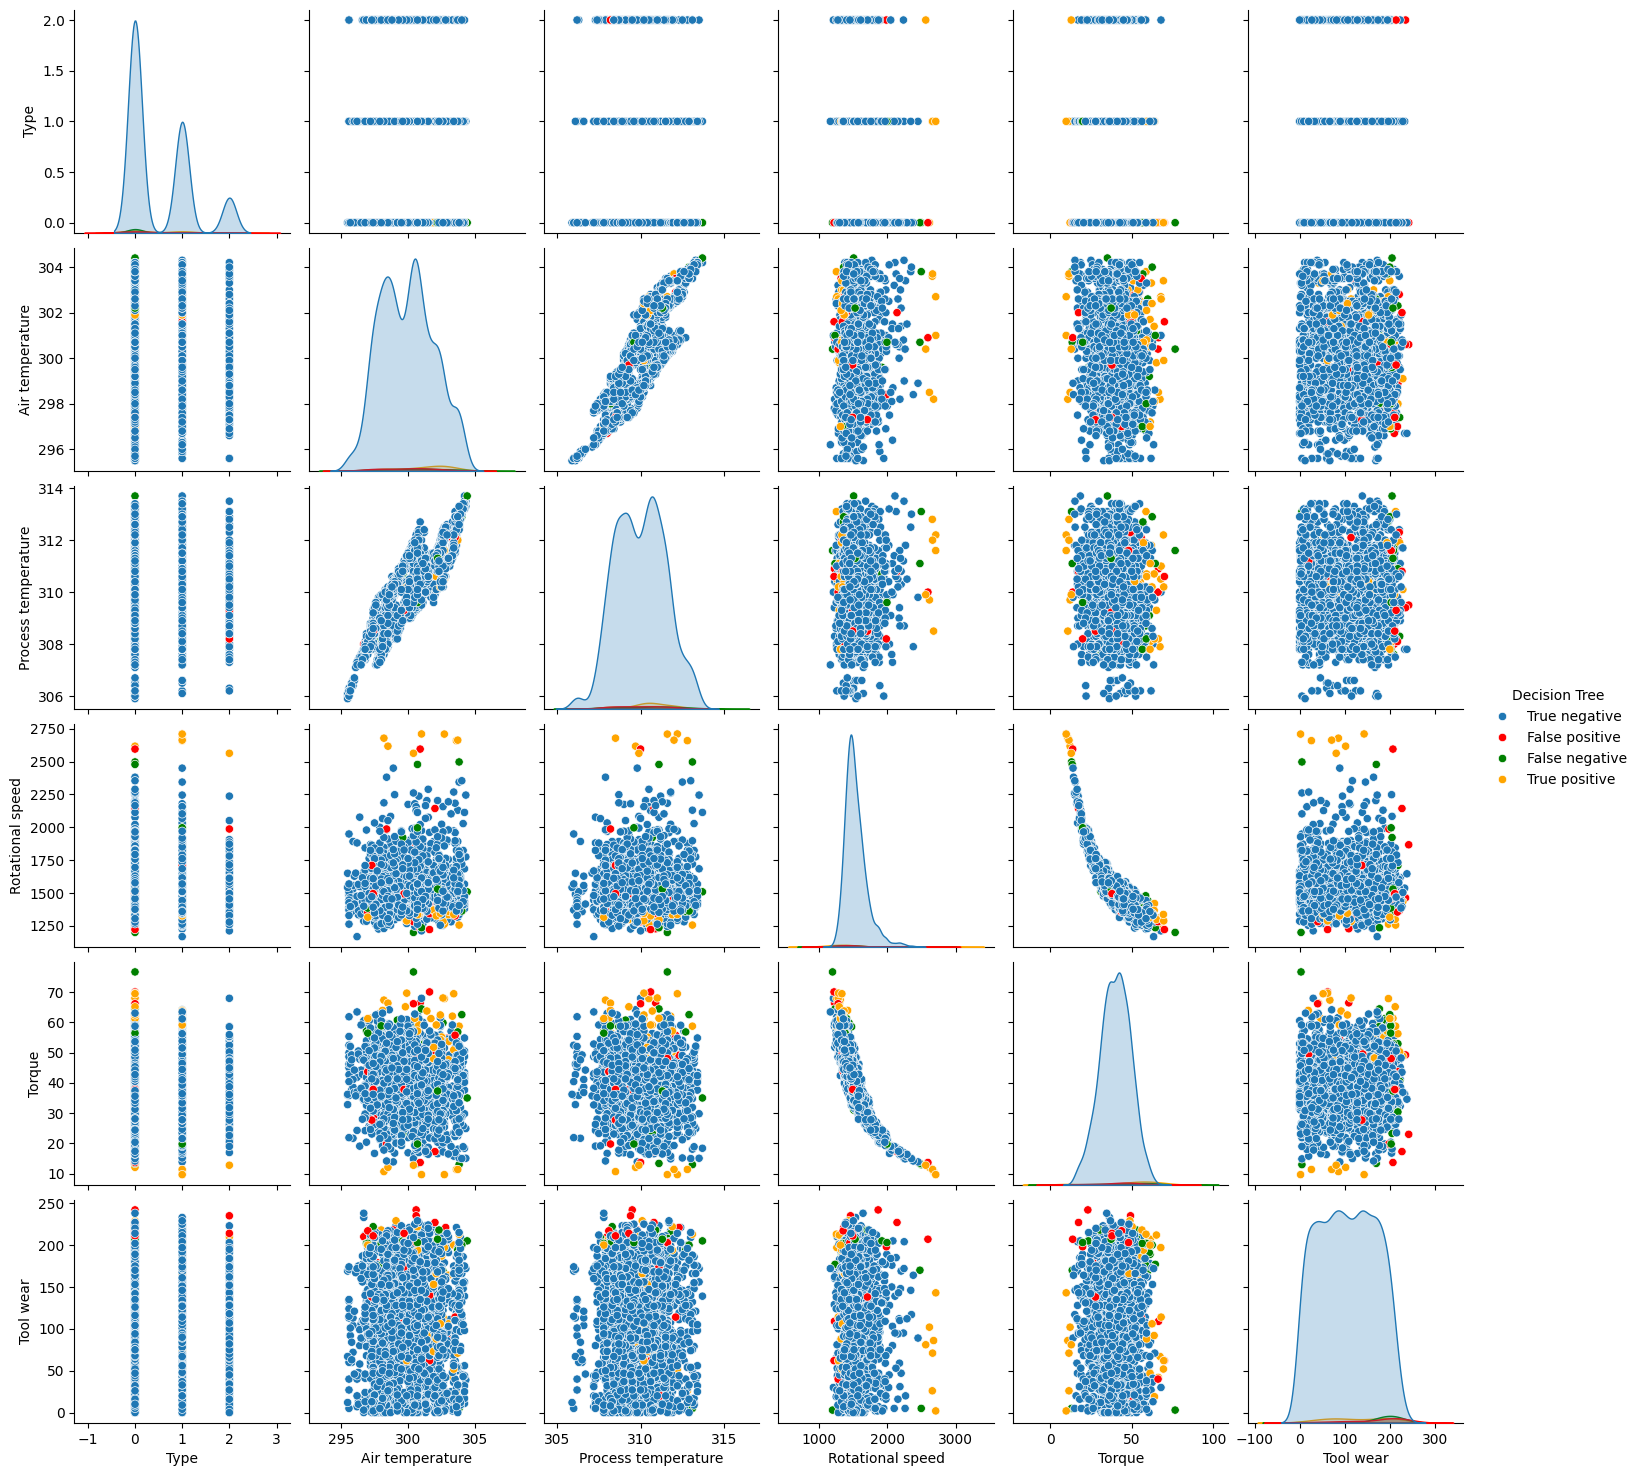

In [35]:
# Plot feature pairs
sns.pairplot(x_dtree, 
             hue='Decision Tree', 
             hue_order=['True negative', 'False positive','False negative', 'True positive'],
             palette=['#1f77b4', 'red', 'green', 'orange'])

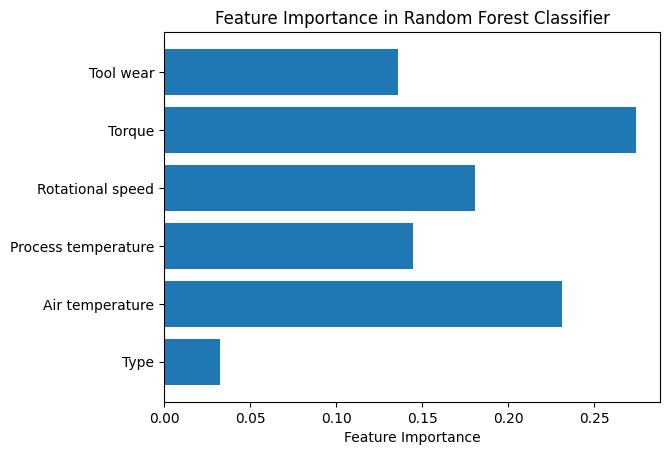

In [36]:
feature_importances = best_dtree.feature_importances_

plt.barh(xtrain.columns, feature_importances)
plt.xlabel('Feature Importance')
plt.title('Feature Importance in Random Forest Classifier')
plt.show()

# Random Forest Implementation

In [37]:
# Random Forest Basic Implementation Form 
rforest = RandomForestClassifier(n_estimators=100)
rforest.fit(xtrain, ytrain)
ypred_rforest = rforest.predict(xtest)
ypred_prob = rforest.predict_proba(xtest)
accuracy_rforest = accuracy_score(ytest, ypred_rforest)
print('Accuracy:', accuracy_rforest)
precision_rforest = precision_score(ytest, ypred_rforest)
print('Precision:', precision_rforest)
recall_rforest = recall_score(ytest, ypred_rforest)
print('Recall:', recall_rforest)


Accuracy: 0.979
Precision: 0.825
Recall: 0.4852941176470588


In [ ]:
# Hyperparameter Tuning of Random Forest 
# Define the parameter grid to tune the hyperparameters
param_grid = {
    'n_estimators': [10, 20, 50, 100],
    'criterion': ['gini', 'entropy', 'log_loss'],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 4, 8],
    'bootstrap': [True, False]
}

#Perform grid search from hyperparameters to find optimal performance
rforest = RandomForestClassifier()
grid_search_rforest = GridSearchCV(estimator=rforest, param_grid=param_grid, 
                           cv=5, n_jobs=-1, verbose=2, scoring='recall')
grid_search_rforest.fit(xtrain, ytrain)
print('best score: {:.3f}, best params: {}'.format(grid_search_rforest.best_score_, grid_search_rforest.best_params_))

Fitting 5 folds for each of 288 candidates, totalling 1440 fits


In [ ]:
# Provide top 5 from grid search table and best parameters.
gs_table = pd.DataFrame(grid_search_rforest.cv_results_)
gs_sort = gs_table.sort_values('rank_test_score', ascending=True)
gs_sort.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_bootstrap,param_criterion,param_max_depth,param_min_samples_split,param_n_estimators,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
174,0.984598,0.055928,0.026960,0.001749,False,gini,30,4,50,"{'bootstrap': False, 'criterion': 'gini', 'max...",0.740741,0.703704,0.611111,0.685185,0.563636,0.660875,0.064398,1
185,0.378680,0.024982,0.015449,0.001444,False,gini,None,4,20,"{'bootstrap': False, 'criterion': 'gini', 'max...",0.685185,0.703704,0.592593,0.740741,0.563636,0.657172,0.067606,2
158,1.174027,0.032113,0.026471,0.003548,False,gini,20,2,50,"{'bootstrap': False, 'criterion': 'gini', 'max...",0.703704,0.703704,0.611111,0.740741,0.509091,0.653670,0.084027,3
162,0.887310,0.047674,0.024640,0.002714,False,gini,20,4,50,"{'bootstrap': False, 'criterion': 'gini', 'max...",0.740741,0.703704,0.629630,0.666667,0.527273,0.653603,0.073223,4
163,1.841330,0.122836,0.039132,0.003495,False,gini,20,4,100,"{'bootstrap': False, 'criterion': 'gini', 'max...",0.722222,0.685185,0.611111,0.703704,0.545455,0.653535,0.065906,5


In [ ]:
# Apply optimal hyperparameter from grid search
best_rforest = grid_search_rforest.best_estimator_
ypred_rforest = best_rforest.predict(xtest)
accuracy_rforest = accuracy_score(ytest, ypred_rforest)
print('Accuracy:', accuracy_rforest)
precision_rforest = precision_score(ytest, ypred_rforest)
print('Precision:', precision_rforest)
recall_rforest = recall_score(ytest, ypred_rforest)
print('Recall:', recall_rforest)

Accuracy: 0.9805
Precision: 0.7843137254901961
Recall: 0.5882352941176471


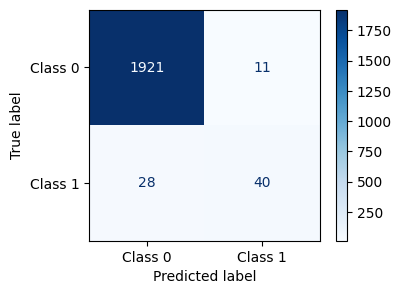

In [ ]:
# Compute the confusion matrix
confuse_matrix(ytest, ypred_rforest)

In [ ]:
x_rforest = xtest.copy()
x_rforest.loc[(ypred_rforest==0) & (ytest==0), 'Random Forest'] = 'True negative'
x_rforest.loc[(ypred_rforest==1) & (ytest==0), 'Random Forest'] = 'False positive'
x_rforest.loc[(ypred_rforest==0) & (ytest==1), 'Random Forest'] = 'False negative'
x_rforest.loc[(ypred_rforest==1) & (ytest==1), 'Random Forest'] = 'True positive'

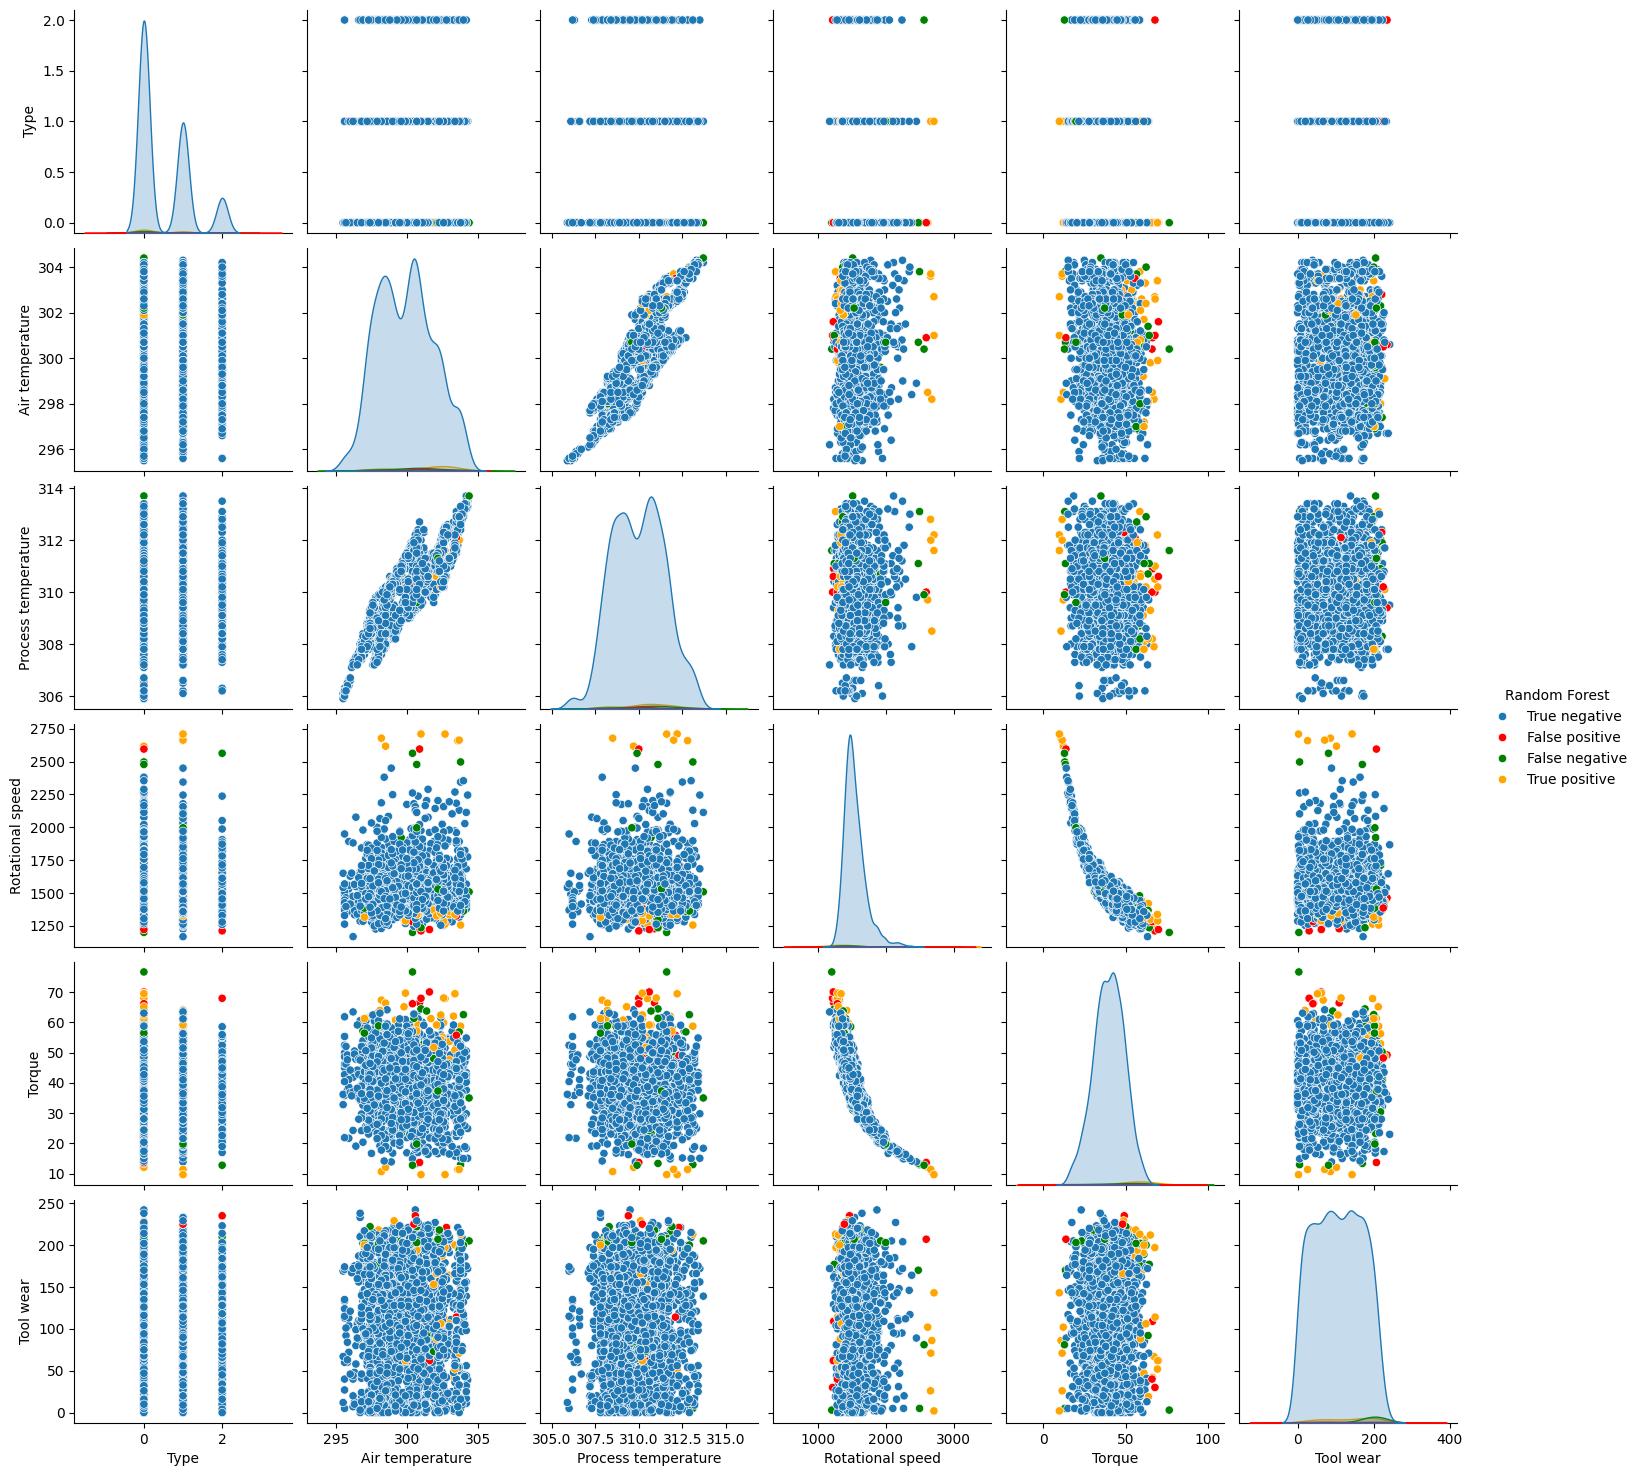

In [ ]:
# Plot feature pairs
sns.pairplot(x_rforest, 
             hue='Random Forest', 
             hue_order=['True negative', 'False positive','False negative', 'True positive'],
             palette=['#1f77b4', 'red', 'green', 'orange'])

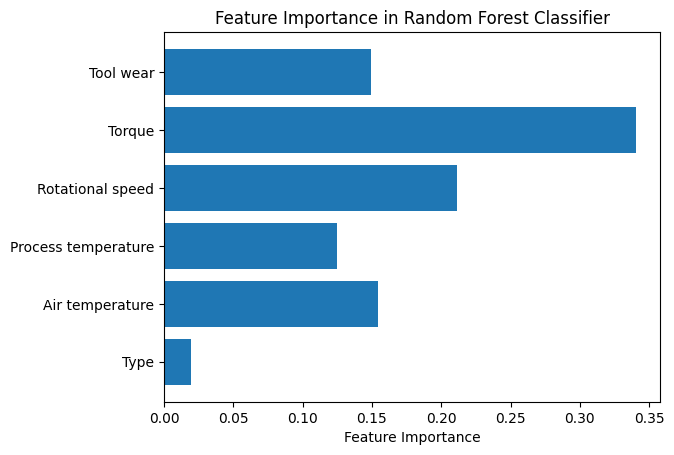

In [ ]:
feature_importances = best_rforest.feature_importances_

plt.barh(xtrain.columns, feature_importances)
plt.xlabel('Feature Importance')
plt.title('Feature Importance in Random Forest Classifier')
plt.show()

# Comparison of algorithm results

In [ ]:
# Generate the training, validation, test results from the three algorithms.
print('kNN algorithm:')
print('  Training set validation score ' + str(max(mean_val_scores.tolist())))
print('  Test set score ' + str(recall_knn))
print('Decision Tree algorithm:')
print('  Training set validation score ' + str(grid_search_dtree.best_score_))
print('  Test set score ' + str(recall_dtree))
print('Random Forest algorithm:')
print('  Training set validation score ' + str(grid_search_rforest.best_score_))
print('  Test set score ' + str(recall_rforest))

kNN algorithm:
  Training set validation score 0.23265993265993265
  Test set score 0.25
Decision Tree algorithm:
  Training set validation score 0.7237037037037037
  Test set score 0.6029411764705882
Random Forest algorithm:
  Training set validation score 0.6608754208754208
  Test set score 0.5882352941176471


# Isolation Forest Implementation

In [ ]:
# Isolation Forest Basic Implementation Form 
iso_forest = IsolationForest(
    n_estimators=100   
    )
iso_forest.fit(xtrain)
ypred_iso_forest = iso_forest.predict(xtest)
anomaly_scores = iso_forest.score_samples(xtest)
accuracy_iso_forest = accuracy_score(ytest, ypred_iso_forest)
print('Accuracy:', accuracy_iso_forest)
precision_iso_forest = precision_score(ytest, ypred_iso_forest)
print('Precision:', precision_iso_forest)
recall_iso_forest = recall_score(ytest, ypred_iso_forest)
print('Recall:', recall_iso_forest)


NameError: name 'IsolationForest' is not defined

In [ ]:
classification_report(ytest, ypred_iso_forest, target_names=['Normal', 'Anolmaly'])

In [ ]:
# Compute the confusion matrix
confuse_matrix(ytest, ypred_rforest)